In [2]:
import pandas as pd
pd.set_option('display.max_columns', None)
import numpy as np

In [47]:
seed=42

In [7]:
df = pd.read_csv("data/processed/df_with_segment_labels.csv")
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,segment,segment_label
0,Female,no,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,1,Low Engagement ⚠️
1,Male,no,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0,2,Stable Mid-Value 👍
2,Male,no,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,2,Stable Mid-Value 👍
3,Male,no,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,2,Stable Mid-Value 👍
4,Female,no,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,3,At risk High-value 🚨


In [8]:
df.shape

(7032, 22)

In [9]:
X = df.drop(['Churn','segment_label'], axis=1)
y = df['Churn']
print(X.shape, y.shape)

(7032, 20) (7032,)


In [10]:
y.value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=seed
)

num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
cat_cols = [col for col in X.columns if col not in num_cols]

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(drop='first'), cat_cols)
])

In [14]:
X_train.shape

(5625, 20)

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.ensemble import AdaBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,)

In [16]:
from sklearn.pipeline import Pipeline

In [17]:
models = {
    "Logistic": LogisticRegression(),
    "RandomForest": RandomForestClassifier(),
    # Boosting
    "AdaBoost": AdaBoostClassifier(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric="logloss"),
    "LightGBM": LGBMClassifier(),
    "catboost": CatBoostClassifier(verbose=0)
}

In [18]:
train_results = {}
test_results={}

for name, model in models.items():
    
    pipe = Pipeline([
        ("prep", preprocessor),
        ("model", model)
    ])
    
    pipe.fit(X_train, y_train)
    
    # Predictions
    y_train_preds = pipe.predict(X_train)
    y_test_preds = pipe.predict(X_test)
    
    # Probabilities
    if hasattr(pipe, "predict_proba"):
        y_train_prob = pipe.predict_proba(X_train)[:, 1]
        y_test_prob = pipe.predict_proba(X_test)[:, 1]
    else:
        y_train_prob = None
        y_test_prob = None

    # ===== Training set performance =====
    train_Accuracy = accuracy_score(y_train, y_train_preds)
    train_Precision = precision_score(y_train, y_train_preds)
    train_Recall = recall_score(y_train, y_train_preds)
    train_F1 = f1_score(y_train, y_train_preds)
    train_ROC_AUC = roc_auc_score(y_train, y_train_prob) if y_train_prob is not None else None

    # ===== Test set performance =====
    test_Accuracy = accuracy_score(y_test, y_test_preds)
    test_Precision = precision_score(y_test, y_test_preds)
    test_Recall = recall_score(y_test, y_test_preds)
    test_F1 = f1_score(y_test, y_test_preds)
    test_ROC_AUC = roc_auc_score(y_test, y_test_prob) if y_test_prob is not None else None

    train_results[name] = {
        "Train_Accuracy": train_Accuracy,
        "Train_Precision": train_Precision,
        "Train_Recall": train_Recall,
        "Train_F1": train_F1,
        "Train_ROC_AUC": train_ROC_AUC
    }
    test_results[name]={
        "Test_Accuracy": test_Accuracy,
        "Test_Precision": test_Precision,
        "Test_Recall": test_Recall,
        "Test_F1": test_F1,
        "Test_ROC_AUC": test_ROC_AUC
    }


c:\Users\USER\anaconda3\envs\ml_env\lib\site-packages\xgboost\training.py:200: UserWarning: [13:50:04] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 1495, number of negative: 4130
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000925 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 643
[LightGBM] [Info] Number of data points in the train set: 5625, number of used features: 33
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265778 -> initscore=-1.016151
[LightGBM] [Info] Start training from score -1.016151


c:\Users\USER\anaconda3\envs\ml_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\USER\anaconda3\envs\ml_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\USER\anaconda3\envs\ml_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\USER\anaconda3\envs\ml_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [19]:
print("\ntrain Summary Metrics:")
pd.DataFrame(train_results).T.sort_values(by="Train_Recall", ascending=False)


train Summary Metrics:


,Train_Accuracy,Train_Precision,Train_Recall,Train_F1,Train_ROC_AUC
RandomForest,0.998756,0.999329,0.995987,0.997655,0.999952
XGBoost,0.942222,0.907382,0.871572,0.889116,0.985709
LightGBM,0.881956,0.824863,0.705686,0.760634,0.953789
catboost,0.879644,0.830372,0.687625,0.752287,0.940189
Logistic,0.809778,0.670683,0.558528,0.609489,0.851555
AdaBoost,0.799644,0.658895,0.510368,0.575198,0.846636


In [20]:
print("\ntest Summary Metrics:")
pd.DataFrame(test_results).T.sort_values(by="Test_Recall", ascending=False)


test Summary Metrics:


,Test_Accuracy,Test_Precision,Test_Recall,Test_F1,Test_ROC_AUC
Logistic,0.800284,0.642202,0.561497,0.599144,0.833957
LightGBM,0.788913,0.617021,0.542781,0.577525,0.829881
XGBoost,0.763326,0.558074,0.526738,0.541953,0.809431
catboost,0.788202,0.622581,0.516043,0.564327,0.827174
RandomForest,0.785359,0.618421,0.502674,0.554572,0.814228
AdaBoost,0.791045,0.638889,0.491979,0.555891,0.834639


## catboost lightGBM XGBoost

In [21]:
y_train.value_counts()

Churn
0    4130
1    1495
Name: count, dtype: int64

In [22]:
4130/1495

2.762541806020067

## catboost with default scale_pos_weight

In [23]:
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report, roc_auc_score

cat_features = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

model = CatBoostClassifier(verbose=0)

model.fit(X_train, y_train, cat_features=cat_features)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1033
           1       0.63      0.53      0.58       374

    accuracy                           0.79      1407
   macro avg       0.74      0.71      0.72      1407
weighted avg       0.78      0.79      0.79      1407

ROC-AUC: 0.8328579341619601


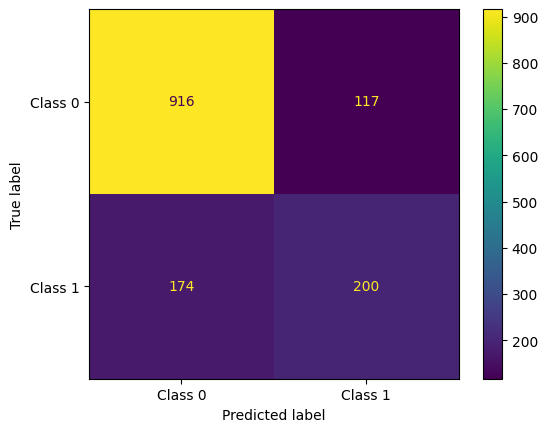

In [24]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["Class 0", "Class 1"])
disp.plot()

plt.show()

CatBoost (with adjusted Scale_Pos_Weight = 3) Deals With Imbalanced Data

In [25]:
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report, roc_auc_score

cat_features = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

model = CatBoostClassifier(verbose=0, scale_pos_weight=3)

model.fit(X_train, y_train, cat_features=cat_features)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.91      0.71      0.79      1033
           1       0.50      0.80      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.80      0.73      0.75      1407

ROC-AUC: 0.8343786075549642


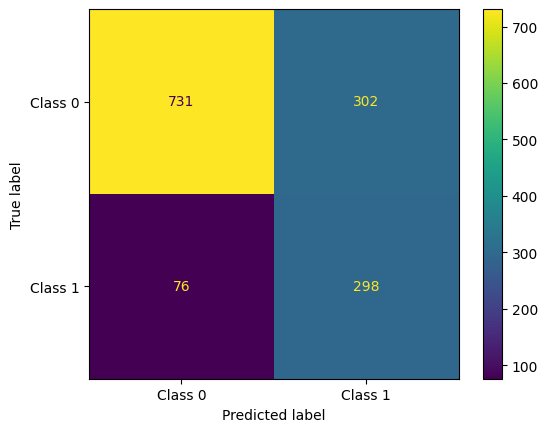

In [26]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# compute confusion matrix
cm = confusion_matrix(y_test, y_pred)
# plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Class 0", "Class 1"])
disp.plot()
plt.show()

CatBoost (with adjusted Scale_Pos_Weight = 2.7) Deals With Imbalanced Data

In [28]:
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report, roc_auc_score

cat_features = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

model = CatBoostClassifier(verbose=0, scale_pos_weight=2.7)

model.fit(X_train, y_train, cat_features=cat_features)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.90      0.73      0.80      1033
           1       0.51      0.78      0.62       374

    accuracy                           0.74      1407
   macro avg       0.71      0.75      0.71      1407
weighted avg       0.80      0.74      0.75      1407

ROC-AUC: 0.8320658898074763


In [32]:
from experiment_logger import log_experiment

report = classification_report(y_test, y_pred, output_dict=True)
roc_auc = roc_auc_score(y_test, y_prob)
# Log
log_experiment(
    model_name="catboost",
    X_train=X_train,
    classification_rep=report,
    roc_auc=roc_auc,
    features_desc="base + segment labels",
    imbalance_handling="pos = 2.7",
    hyperparameters="default",
    notes="trained on (df_with_segement_labels.csv) with scale weight 2.7"
)

import pandas as pd
exp_log= pd.read_csv("experiment_log.csv")
exp_log

✅ Experiment exp_005 logged successfully!


,experiment_id,timestamp,model,features,feature_count,imbalance_handling,hyperparameters,roc_auc,precision_0,recall_0,f1_0,precision_1,recall_1,f1_1,notes
0,exp_001,2026-04-05 20:56:36.571349,Logistic (baseline),base(encoded features),19,NaN,default,0.836071,0.851577,0.888674,0.869730,0.650456,0.572193,0.608819,Clean baseline with just encoding features
1,exp_002,2026-04-06 20:38:36.518022,Logistic (baseline),base+ numberOfServices scaled,20,NaN,default,0.836007,0.852230,0.887706,0.869606,0.649547,0.574866,0.609929,baseline model with scaled num of services as ...
2,exp_003,2026-04-11 12:59:15.247340,logistic,base + 12 engineered,31,NaN,NaN,0.833304,0.838828,0.886738,0.862118,0.628571,0.529412,0.574746,trained on (base_plus_engineered.csv)
3,exp_004,2026-04-11 13:16:56.911720,Logistic (baseline),base + segment labels,20,NaN,default,0.833957,0.848148,0.886738,0.867014,0.642202,0.561497,0.599144,trained on (df_with_segment_label.csv)
4,exp_005,2026-04-11 14:01:11.093331,catboost,base + segment labels,20,pos = 2.7,default,0.832066,0.902527,0.726041,0.804721,0.508681,0.783422,0.616842,trained on (df_with_segement_labels.csv) with ...


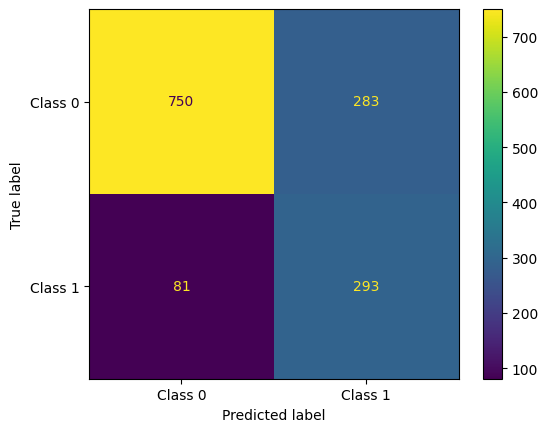

In [29]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# compute confusion matrix
cm = confusion_matrix(y_test, y_pred)
# plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Class 0", "Class 1"])
disp.plot()
plt.show()

In [33]:
import shap

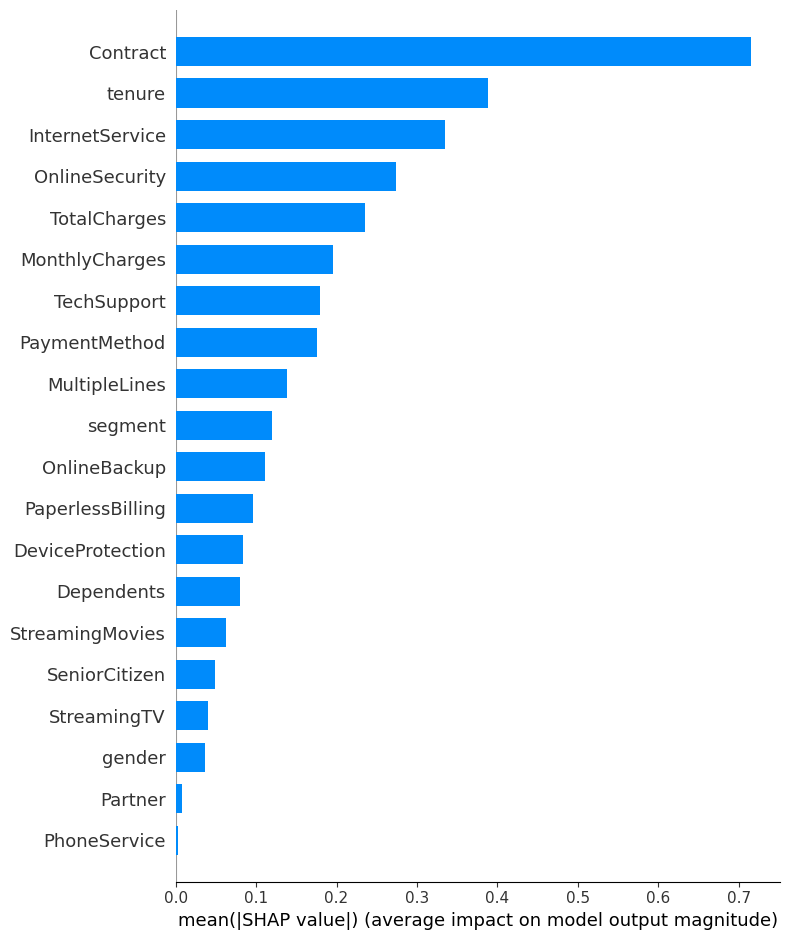

In [34]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test, plot_type="bar")

# XGBoost

XGBoost (with adjusted Scale_Pos_Weight = 2) Deals With Imbalanced Data 

In [35]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

pipeline = Pipeline([
    ('prep', preprocessor),
    ('model', XGBClassifier(
        use_label_encoder=False,
        eval_metric="logloss",
        scale_pos_weight=2
    ))
])

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

c:\Users\USER\anaconda3\envs\ml_env\lib\site-packages\xgboost\training.py:200: UserWarning: [14:02:02] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

           0       0.86      0.80      0.83      1033
           1       0.54      0.64      0.59       374

    accuracy                           0.76      1407
   macro avg       0.70      0.72      0.71      1407
weighted avg       0.78      0.76      0.76      1407

ROC-AUC: 0.81298564484317


In [36]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

pipeline = Pipeline([
    ('prep', preprocessor),
    ('model', XGBClassifier(
        use_label_encoder=False,
        eval_metric="logloss",
        scale_pos_weight=3
    ))
])

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

c:\Users\USER\anaconda3\envs\ml_env\lib\site-packages\xgboost\training.py:200: UserWarning: [14:02:10] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

           0       0.87      0.78      0.82      1033
           1       0.53      0.69      0.60       374

    accuracy                           0.75      1407
   macro avg       0.70      0.73      0.71      1407
weighted avg       0.78      0.75      0.76      1407

ROC-AUC: 0.8167180891541692


In [38]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

pipeline = Pipeline([
    ('prep', preprocessor),
    ('model', XGBClassifier(
        use_label_encoder=False,
        eval_metric="logloss",
        scale_pos_weight=2.7
    ))
])

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

c:\Users\USER\anaconda3\envs\ml_env\lib\site-packages\xgboost\training.py:200: UserWarning: [14:02:34] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

           0       0.87      0.79      0.83      1033
           1       0.54      0.68      0.60       374

    accuracy                           0.76      1407
   macro avg       0.70      0.73      0.71      1407
weighted avg       0.78      0.76      0.77      1407

ROC-AUC: 0.8153125986819968


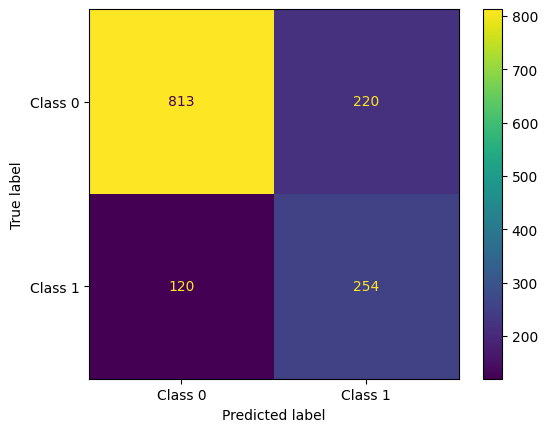

In [39]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# compute confusion matrix
cm = confusion_matrix(y_test, y_pred)
# plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Class 0", "Class 1"])
disp.plot()
plt.show()

In [40]:
from experiment_logger import log_experiment

report = classification_report(y_test, y_pred, output_dict=True)
roc_auc = roc_auc_score(y_test, y_prob)
# Log
log_experiment(
    model_name="XGBoost",
    X_train=X_train,
    classification_rep=report,
    roc_auc=roc_auc,
    features_desc="base + segment labels",
    imbalance_handling="pos = 2.7",
    hyperparameters="default",
    notes="trained on (df_with_segement_labels.csv) with scale weight 2.7"
)

import pandas as pd
exp_log= pd.read_csv("experiment_log.csv")
exp_log

✅ Experiment exp_006 logged successfully!


,experiment_id,timestamp,model,features,feature_count,imbalance_handling,hyperparameters,roc_auc,precision_0,recall_0,f1_0,precision_1,recall_1,f1_1,notes
0,exp_001,2026-04-05 20:56:36.571349,Logistic (baseline),base(encoded features),19,NaN,default,0.836071,0.851577,0.888674,0.869730,0.650456,0.572193,0.608819,Clean baseline with just encoding features
1,exp_002,2026-04-06 20:38:36.518022,Logistic (baseline),base+ numberOfServices scaled,20,NaN,default,0.836007,0.852230,0.887706,0.869606,0.649547,0.574866,0.609929,baseline model with scaled num of services as ...
2,exp_003,2026-04-11 12:59:15.247340,logistic,base + 12 engineered,31,NaN,NaN,0.833304,0.838828,0.886738,0.862118,0.628571,0.529412,0.574746,trained on (base_plus_engineered.csv)
3,exp_004,2026-04-11 13:16:56.911720,Logistic (baseline),base + segment labels,20,NaN,default,0.833957,0.848148,0.886738,0.867014,0.642202,0.561497,0.599144,trained on (df_with_segment_label.csv)
4,exp_005,2026-04-11 14:01:11.093331,catboost,base + segment labels,20,pos = 2.7,default,0.832066,0.902527,0.726041,0.804721,0.508681,0.783422,0.616842,trained on (df_with_segement_labels.csv) with ...
5,exp_006,2026-04-11 14:03:04.172549,XGBoost,base + segment labels,20,pos = 2.7,default,0.815313,0.871383,0.787028,0.827060,0.535865,0.679144,0.599057,trained on (df_with_segement_labels.csv) with ...


## lightGBM

In [41]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

pipeline = Pipeline([
    ('prep', preprocessor),
    ('model', LGBMClassifier(scale_pos_weight=2))
])

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

[LightGBM] [Info] Number of positive: 1495, number of negative: 4130
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000445 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 643
[LightGBM] [Info] Number of data points in the train set: 5625, number of used features: 33
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265778 -> initscore=-1.016151
[LightGBM] [Info] Start training from score -1.016151
              precision    recall  f1-score   support

           0       0.88      0.79      0.83      1033
           1       0.55      0.70      0.61       374

    accuracy                           0.76      1407
   macro avg       0.71      0.74      0.72      1407
weighted avg       0.79      0.76      0.77      1407

ROC-AUC: 0.8285767532393579


c:\Users\USER\anaconda3\envs\ml_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\USER\anaconda3\envs\ml_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [42]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

pipeline = Pipeline([
    ('prep', preprocessor),
    ('model', LGBMClassifier(scale_pos_weight=3))
])

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

[LightGBM] [Info] Number of positive: 1495, number of negative: 4130
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000272 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 643
[LightGBM] [Info] Number of data points in the train set: 5625, number of used features: 33
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265778 -> initscore=-1.016151
[LightGBM] [Info] Start training from score -1.016151
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1033
           1       0.50      0.78      0.61       374

    accuracy                           0.74      1407
   macro avg       0.70      0.75      0.71      1407
weighted avg       0.80      0.74      0.75      1407

ROC-AUC: 0.825635059092721


c:\Users\USER\anaconda3\envs\ml_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\USER\anaconda3\envs\ml_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [43]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

pipeline = Pipeline([
    ('prep', preprocessor),
    ('model', LGBMClassifier(scale_pos_weight=2.7))
])

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

[LightGBM] [Info] Number of positive: 1495, number of negative: 4130
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001819 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 643
[LightGBM] [Info] Number of data points in the train set: 5625, number of used features: 33
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265778 -> initscore=-1.016151
[LightGBM] [Info] Start training from score -1.016151
              precision    recall  f1-score   support

           0       0.89      0.73      0.80      1033
           1       0.50      0.75      0.60       374

    accuracy                           0.74      1407
   macro avg       0.70      0.74      0.70      1407
weighted avg       0.79      0.74      0.75      1407

ROC-AUC: 0.8230855045529608


c:\Users\USER\anaconda3\envs\ml_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\USER\anaconda3\envs\ml_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [44]:
from experiment_logger import log_experiment

report = classification_report(y_test, y_pred, output_dict=True)
roc_auc = roc_auc_score(y_test, y_prob)
# Log
log_experiment(
    model_name="lightGBM",
    X_train=X_train,
    classification_rep=report,
    roc_auc=roc_auc,
    features_desc="base + segment labels",
    imbalance_handling="pos = 2.7",
    hyperparameters="default",
    notes="trained on (df_with_segement_labels.csv) with scale weight 2.7"
)

import pandas as pd
exp_log= pd.read_csv("experiment_log.csv")
exp_log

✅ Experiment exp_007 logged successfully!


,experiment_id,timestamp,model,features,feature_count,imbalance_handling,hyperparameters,roc_auc,precision_0,recall_0,f1_0,precision_1,recall_1,f1_1,notes
0,exp_001,2026-04-05 20:56:36.571349,Logistic (baseline),base(encoded features),19,NaN,default,0.836071,0.851577,0.888674,0.869730,0.650456,0.572193,0.608819,Clean baseline with just encoding features
1,exp_002,2026-04-06 20:38:36.518022,Logistic (baseline),base+ numberOfServices scaled,20,NaN,default,0.836007,0.852230,0.887706,0.869606,0.649547,0.574866,0.609929,baseline model with scaled num of services as ...
2,exp_003,2026-04-11 12:59:15.247340,logistic,base + 12 engineered,31,NaN,NaN,0.833304,0.838828,0.886738,0.862118,0.628571,0.529412,0.574746,trained on (base_plus_engineered.csv)
3,exp_004,2026-04-11 13:16:56.911720,Logistic (baseline),base + segment labels,20,NaN,default,0.833957,0.848148,0.886738,0.867014,0.642202,0.561497,0.599144,trained on (df_with_segment_label.csv)
4,exp_005,2026-04-11 14:01:11.093331,catboost,base + segment labels,20,pos = 2.7,default,0.832066,0.902527,0.726041,0.804721,0.508681,0.783422,0.616842,trained on (df_with_segement_labels.csv) with ...
5,exp_006,2026-04-11 14:03:04.172549,XGBoost,base + segment labels,20,pos = 2.7,default,0.815313,0.871383,0.787028,0.827060,0.535865,0.679144,0.599057,trained on (df_with_segement_labels.csv) with ...
6,exp_007,2026-04-11 14:03:47.984960,lightGBM,base + segment labels,20,pos = 2.7,default,0.823086,0.888498,0.732817,0.803183,0.502703,0.745989,0.600646,trained on (df_with_segement_labels.csv) with ...


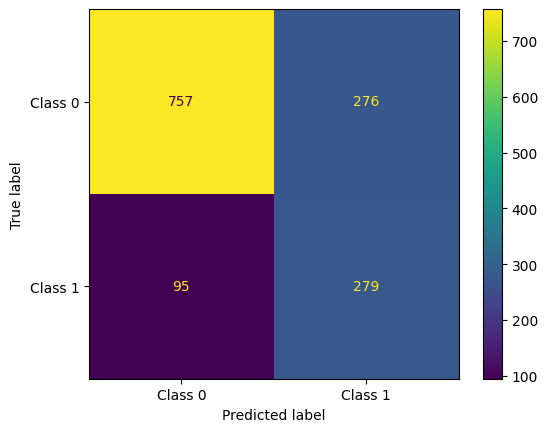

In [45]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# compute confusion matrix
cm = confusion_matrix(y_test, y_pred)
# plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Class 0", "Class 1"])
disp.plot()
plt.show()

## feature engineering 3

In [48]:
df = pd.read_csv("data/processed/df_with_segment_labels.csv")
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,segment,segment_label
0,Female,no,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,1,Low Engagement ⚠️
1,Male,no,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0,2,Stable Mid-Value 👍
2,Male,no,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,2,Stable Mid-Value 👍
3,Male,no,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,2,Stable Mid-Value 👍
4,Female,no,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,3,At risk High-value 🚨


In [50]:
df.shape

(7032, 22)

In [51]:
# --- Tenure band (categorical) ---
df['tenure_band'] = pd.cut(
    df['tenure'],
    bins=[0, 12, 36, 72],
    labels=['0-12', '12-36', '36+'],
    right=True
)
df['tenure_band'] = df['tenure_band'].astype(str)

In [52]:
# --- Service usage counts (numeric) ---
streamning_services = ['StreamingTV','StreamingMovies']
df['streaming_count'] = ((df[streamning_services] == 'Yes') | (df[streamning_services] == 'yes')).sum(axis=1)

security_services = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport']
df['security_count'] = ((df[security_services] == 'Yes') | (df[security_services] == 'yes')).sum(axis=1)   

In [53]:
df['month_to_month_paperless'] = (
    (df['Contract'] == 'Month-to-month') &
    (df['PaperlessBilling'] == 'Yes')
).astype(int)

In [54]:
df['no_support_services'] = ((df['TechSupport'] == 'No') &(df['OnlineSecurity'] == 'No')).astype(int)
    
df['is_isolated'] = ((df['Partner'] == 'No') &(df['Dependents'] == 'No')).astype(int)

In [55]:
df.shape

(7032, 28)

In [56]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,segment,segment_label,tenure_band,streaming_count,security_count,month_to_month_paperless,no_support_services,is_isolated
0,Female,no,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,1,Low Engagement ⚠️,0-12,0,1,1,1,0
1,Male,no,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0,2,Stable Mid-Value 👍,12-36,0,2,0,0,1
2,Male,no,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,2,Stable Mid-Value 👍,0-12,0,2,1,0,1
3,Male,no,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,2,Stable Mid-Value 👍,36+,0,3,0,0,1
4,Female,no,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,3,At risk High-value 🚨,0-12,0,0,1,1,1


In [58]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn', 'segment', 'segment_label',
       'tenure_band', 'streaming_count', 'security_count',
       'month_to_month_paperless', 'no_support_services', 'is_isolated'],
      dtype='object')

In [57]:
X = df.drop(['Churn','segment_label'], axis=1)
y = df['Churn']
print(X.shape, y.shape)

(7032, 26) (7032,)


In [59]:
X.dtypes

gender                       object
SeniorCitizen                object
Partner                      object
Dependents                   object
tenure                        int64
PhoneService                 object
MultipleLines                object
InternetService              object
OnlineSecurity               object
OnlineBackup                 object
DeviceProtection             object
TechSupport                  object
StreamingTV                  object
StreamingMovies              object
Contract                     object
PaperlessBilling             object
PaymentMethod                object
MonthlyCharges              float64
TotalCharges                float64
segment                       int64
tenure_band                  object
streaming_count               int64
security_count                int64
month_to_month_paperless      int64
no_support_services           int64
is_isolated                   int64
dtype: object

In [ ]:
# num_cols= [tenure, MonthlyCharges, TotalCharges,
# streaming_count, security_count,
# month_to_month_paperless, no_support_services, is_isolated]

# cat_cols= [gender, PhoneService, MultipleLines, InternetService,
# OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport,
# StreamingTV, StreamingMovies, Contract, PaperlessBilling,
# PaymentMethod, segment, tenure_band]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=seed
)


### catboost

In [61]:
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report, roc_auc_score

cat_features = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

model = CatBoostClassifier(verbose=0)

model.fit(X_train, y_train, cat_features=cat_features)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1033
           1       0.63      0.53      0.57       374

    accuracy                           0.79      1407
   macro avg       0.73      0.71      0.72      1407
weighted avg       0.78      0.79      0.79      1407

ROC-AUC: 0.8289533625647743


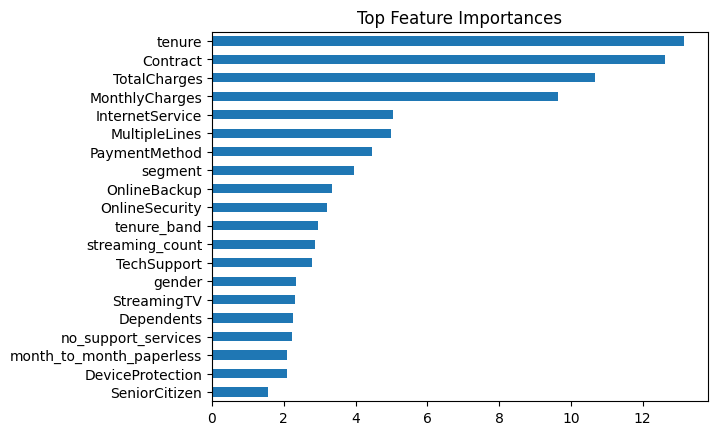

In [ ]:
# =========================
# FEATURE IMPORTANCE
# =========================
import matplotlib.pyplot as plt

importances = model.get_feature_importance()
feature_names = X.columns

feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

feat_imp.head(20).plot(kind='barh')
plt.title("Top Feature Importances")
plt.gca().invert_yaxis()
plt.show()

# Hyperparameter tunning 

In [5]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.model_selection import (
    train_test_split, RandomizedSearchCV,
    StratifiedKFold, cross_val_score
)
from sklearn.metrics import roc_auc_score, classification_report, make_scorer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

from xgboost import XGBClassifier
from catboost import CatBoostClassifier, Pool
from lightgbm import LGBMClassifier

ImportError: DLL load failed while importing _multiarray_umath: The specified module could not be found.

ImportError: numpy._core.multiarray failed to import

In [6]:
df = pd.read_csv("data/processed/df_with_segment_labels.csv")
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,segment,segment_label
0,Female,no,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,1,Low Engagement ⚠️
1,Male,no,No,No,34,Yes,No,DSL,Yes,No,...,No,No,One year,No,Mailed check,56.95,1889.50,0,2,Stable Mid-Value 👍
2,Male,no,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,2,Stable Mid-Value 👍
3,Male,no,No,No,45,No,No phone service,DSL,Yes,No,...,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,2,Stable Mid-Value 👍
4,Female,no,No,No,2,Yes,No,Fiber optic,No,No,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,3,At risk High-value 🚨


In [7]:
X = df.drop(['Churn','segment_label'], axis=1)
y = df['Churn']

In [8]:
# Train / Validation / Test split
# 70% train | 15% val | 15% test
# ─────────────────────────────────────────
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=42, stratify=y_temp
    # 0.176 of 85% ≈ 15% of total
)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

# Cross-validation object (used in Phase 1)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

Train: (4925, 20), Val: (1052, 20), Test: (1055, 20)


In [9]:
cat_cols = X.select_dtypes(include='object').columns.tolist()
cat_cols.append('segment')  # treat segment as categorical
cat_cols = list(set(cat_cols))
num_cols = [c for c in X.columns if c not in cat_cols]

In [10]:
cat_cols,num_cols

(['SeniorCitizen',
  'PaperlessBilling',
  'PaymentMethod',
  'OnlineBackup',
  'PhoneService',
  'segment',
  'StreamingMovies',
  'TechSupport',
  'gender',
  'Dependents',
  'Partner',
  'MultipleLines',
  'Contract',
  'StreamingTV',
  'DeviceProtection',
  'InternetService',
  'OnlineSecurity'],
 ['tenure', 'MonthlyCharges', 'TotalCharges'])

In [11]:
# ─── For XGBoost and LightGBM ───
# These need numeric encoding; use OrdinalEncoder for simplicity here
# (or OneHotEncoder if you prefer)
preprocessor_ord = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(drop='first'), cat_cols)
])

# ─── For CatBoost ───
# CatBoost handles categoricals natively — we pass cat_feature indices directly
# So we need a raw (unencoded) matrix with cat feature indices

# Encode cat cols as string to ensure CatBoost treats them as categorical
X_train_cb = X_train.copy()
X_val_cb   = X_val.copy()
X_test_cb  = X_test.copy()

for col in cat_cols:
    X_train_cb[col] = X_train_cb[col].astype(str)
    X_val_cb[col]   = X_val_cb[col].astype(str)
    X_test_cb[col]  = X_test_cb[col].astype(str)

cat_feature_indices = [X_train_cb.columns.get_loc(c) for c in cat_cols]

# CatBoost Pool objects
train_pool = Pool(X_train_cb, y_train, cat_features=cat_feature_indices)
val_pool   = Pool(X_val_cb,   y_val,   cat_features=cat_feature_indices)
test_pool  = Pool(X_test_cb,  y_test,  cat_features=cat_feature_indices)

# Preprocessed data for XGB and LGBM
X_train_enc = preprocessor_ord.fit_transform(X_train)
X_val_enc   = preprocessor_ord.transform(X_val)
X_test_enc  = preprocessor_ord.transform(X_test)

## ══ PHASE 1: RandomizedSearchCV — Broad Exploration ══

Phase 1A — XGBoost

In [27]:
xgb_param_dist = {
    'n_estimators':        [100, 200, 300, 500],
    'max_depth':           [3, 4, 5, 6, 7, 8],
    'learning_rate':       [0.01, 0.05, 0.1, 0.2, 0.3],
    'subsample':           [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree':    [0.5, 0.6, 0.7, 0.8, 1.0],
    'min_child_weight':    [1, 3, 5, 7, 10],
    'reg_alpha':           [0, 0.01, 0.1, 0.5, 1.0],
    'reg_lambda':          [0.5, 1.0, 2.0, 5.0],
    'gamma':               [0, 0.1, 0.3, 0.5, 1.0],
    'scale_pos_weight':    [2, 2.5, 2.7, 3]
}

xgb_base = XGBClassifier(
    eval_metric='auc',
    use_label_encoder=False,
    random_state=42,
    n_jobs=-1
)

xgb_random = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=xgb_param_dist,
    n_iter=60,
    scoring='roc_auc',
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

xgb_random.fit(X_train_enc, y_train)

print(f"\n[XGB Phase 1] Best AUC: {xgb_random.best_score_:.4f}")
print(f"[XGB Phase 1] Best Params:\n{xgb_random.best_params_}")

xgb_phase1_params = xgb_random.best_params_

Fitting 5 folds for each of 60 candidates, totalling 300 fits

[XGB Phase 1] Best AUC: 0.8519
[XGB Phase 1] Best Params:
{'subsample': 0.9, 'scale_pos_weight': 2, 'reg_lambda': 1.0, 'reg_alpha': 1.0, 'n_estimators': 500, 'min_child_weight': 5, 'max_depth': 4, 'learning_rate': 0.01, 'gamma': 0.3, 'colsample_bytree': 0.6}


Phase 1B — LightGBM

In [28]:
lgbm_param_dist = {
    'n_estimators':        [100, 200, 300, 500],
    'max_depth':           [-1, 4, 6, 8, 10],
    'learning_rate':       [0.01, 0.05, 0.1, 0.2],
    'num_leaves':          [20, 31, 50, 70, 100],
    'min_child_samples':   [10, 20, 30, 50],
    'subsample':           [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree':    [0.5, 0.6, 0.7, 0.8, 1.0],
    'reg_alpha':           [0, 0.01, 0.1, 0.5],
    'reg_lambda':          [0, 0.1, 0.5, 1.0],
    'scale_pos_weight':    [2, 2.5, 2.7, 3]
}

lgbm_base = LGBMClassifier(
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

lgbm_random = RandomizedSearchCV(
    estimator=lgbm_base,
    param_distributions=lgbm_param_dist,
    n_iter=60,
    scoring='roc_auc',
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

lgbm_random.fit(X_train_enc, y_train)

print(f"\n[LGBM Phase 1] Best AUC: {lgbm_random.best_score_:.4f}")
print(f"[LGBM Phase 1] Best Params:\n{lgbm_random.best_params_}")

lgbm_phase1_params = lgbm_random.best_params_

Fitting 5 folds for each of 60 candidates, totalling 300 fits

[LGBM Phase 1] Best AUC: 0.8504
[LGBM Phase 1] Best Params:
{'subsample': 1.0, 'scale_pos_weight': 2.7, 'reg_lambda': 1.0, 'reg_alpha': 0, 'num_leaves': 20, 'n_estimators': 300, 'min_child_samples': 20, 'max_depth': 10, 'learning_rate': 0.01, 'colsample_bytree': 0.7}


Phase 1C — CatBoost

In [29]:
from sklearn.model_selection import StratifiedKFold
from catboost import CatBoostClassifier, Pool
from sklearn.metrics import roc_auc_score
import numpy as np
from scipy.stats import randint, uniform
import random

# ─────────────────────────────────────────
# Phase 1C — CatBoost Manual RandomSearch
# ─────────────────────────────────────────

def sample_catboost_params(seed=None):
    rng = np.random.RandomState(seed)
    return {
        'iterations':          int(rng.choice([100, 200, 300, 500])),
        'depth':               int(rng.choice([4, 5, 6, 7, 8])),
        'learning_rate':       float(rng.choice([0.01, 0.05, 0.1, 0.2])),
        'l2_leaf_reg':         float(rng.choice([1, 3, 5, 7, 10])),
        'bagging_temperature': float(rng.choice([0.0, 0.5, 1.0, 2.0])),
        'border_count':        int(rng.choice([32, 64, 128])),
        'random_strength':     float(rng.choice([0.5, 1.0, 2.0, 3.0])),
        # 🔥 Added imbalance handling
        'scale_pos_weight':    float(rng.choice([2, 2.5, 2.7, 3]))
    }


def manual_catboost_random_search(
    X, y,
    cat_feature_indices,
    n_iter=40,
    n_splits=5,
    random_state=42
):
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    
    best_score  = -np.inf
    best_params = None
    all_results = []

    for i in range(n_iter):
        params = sample_catboost_params(seed=random_state + i)
        fold_scores = []

        for fold, (train_idx, val_idx) in enumerate(cv.split(X, y)):
            X_tr, X_vl = X.iloc[train_idx], X.iloc[val_idx]
            y_tr, y_vl = y.iloc[train_idx], y.iloc[val_idx]

            # Ensure cat cols are string type
            train_pool = Pool(X_tr, y_tr, cat_features=cat_feature_indices)
            val_pool   = Pool(X_vl, y_vl, cat_features=cat_feature_indices)

            model = CatBoostClassifier(
                **params,
                eval_metric='AUC',
                # auto_class_weights='Balanced',
                random_seed=random_state,
                verbose=0,
                early_stopping_rounds=20
            )

            model.fit(train_pool, eval_set=val_pool, use_best_model=True)

            preds = model.predict_proba(val_pool)[:, 1]
            fold_scores.append(roc_auc_score(y_vl, preds))

        mean_auc = np.mean(fold_scores)
        all_results.append({'params': params, 'mean_auc': mean_auc})

        print(f"  Iter {i+1:02d}/{n_iter} | AUC: {mean_auc:.4f} | params: {params}")

        if mean_auc > best_score:
            best_score  = mean_auc
            best_params = params

    print(f"\n[CatBoost Phase 1] Best CV AUC : {best_score:.4f}")
    print(f"[CatBoost Phase 1] Best Params  : {best_params}")

    return best_params, best_score, all_results


# Run it
cb_phase1_params, cb_phase1_score, cb_phase1_results = manual_catboost_random_search(
    X=X_train_cb,
    y=y_train,
    cat_feature_indices=cat_feature_indices,
    n_iter=10,
    n_splits=5,
    random_state=42
)

  Iter 01/10 | AUC: 0.8453 | params: {'iterations': 300, 'depth': 7, 'learning_rate': 0.01, 'l2_leaf_reg': 5.0, 'bagging_temperature': 2.0, 'border_count': 32, 'random_strength': 0.5, 'scale_pos_weight': 2.7}
  Iter 02/10 | AUC: 0.8515 | params: {'iterations': 100, 'depth': 4, 'learning_rate': 0.2, 'l2_leaf_reg': 3.0, 'bagging_temperature': 0.5, 'border_count': 128, 'random_strength': 0.5, 'scale_pos_weight': 3.0}
  Iter 03/10 | AUC: 0.8516 | params: {'iterations': 100, 'depth': 7, 'learning_rate': 0.05, 'l2_leaf_reg': 7.0, 'bagging_temperature': 2.0, 'border_count': 32, 'random_strength': 0.5, 'scale_pos_weight': 3.0}
  Iter 04/10 | AUC: 0.8449 | params: {'iterations': 500, 'depth': 7, 'learning_rate': 0.01, 'l2_leaf_reg': 1.0, 'bagging_temperature': 2.0, 'border_count': 64, 'random_strength': 1.0, 'scale_pos_weight': 3.0}
  Iter 05/10 | AUC: 0.8398 | params: {'iterations': 200, 'depth': 4, 'learning_rate': 0.01, 'l2_leaf_reg': 5.0, 'bagging_temperature': 2.0, 'border_count': 128, 'ra

## phase 2 optuna

In [30]:
# Just organizing the Phase 1 best params clearly for reference
xgb_phase1_params = {
    'subsample': 0.9, 'reg_lambda': 1.0,
    'reg_alpha': 1.0, 'n_estimators': 500, 'min_child_weight': 5,
    'max_depth': 4, 'learning_rate': 0.01, 'gamma': 0.3, 'colsample_bytree': 0.6,
    'scale_pos_weight': 2
}

lgbm_phase1_params = {
    'subsample': 1.0, 'reg_lambda': 1.0, 'reg_alpha': 0,
    'num_leaves': 20, 'n_estimators': 300, 'min_child_samples': 20,
    'max_depth': 10, 'learning_rate': 0.01, 'colsample_bytree': 0.7,
    'scale_pos_weight': 2.7
}

cb_phase1_params = {
    'iterations': 100, 'depth': 4, 'learning_rate': 0.2,
    'l2_leaf_reg': 3.0, 'bagging_temperature': 1.0,
    'border_count': 32, 'random_strength': 2.0, 'scale_pos_weight': 2.5
}

# Print narrowed ranges for each
print("=== XGB Narrowed Search Space ===")
print(f"n_estimators   : [{max(100, 500-200)}, {500+300}]   (phase1=500)")
print(f"max_depth      : [{max(3,4-1)}, {4+2}]              (phase1=4)")
print(f"learning_rate  : [{0.01*0.4:.4f}, {0.01*4:.4f}]     (phase1=0.01)")
print(f"subsample      : [{max(0.5,0.9-0.15):.2f}, {min(1.0,0.9+0.10):.2f}]  (phase1=0.9)")
print(f"colsample_bytree:[{max(0.5,0.6-0.15):.2f}, {min(1.0,0.6+0.20):.2f}]  (phase1=0.6)")
print(f"min_child_weight:[{max(1,5-2)}, {5+4}]              (phase1=5)")
print(f"gamma          : [{max(0,0.3-0.2):.2f}, {0.3+0.3:.2f}]              (phase1=0.3)")
print(f"reg_alpha      : [{max(0,1.0-0.8):.2f}, {1.0+1.0:.2f}]              (phase1=1.0)")
print(f"reg_lambda     : [{max(0.1,1.0-0.5):.2f}, {1.0+1.5:.2f}]            (phase1=1.0)")
print(f"scale_pos_weight:[{max(1,2-1)}, {2+3}]              (phase1=2)")

print("\n=== LGBM Narrowed Search Space ===")
print(f"n_estimators   : [{max(200,300-100)}, {300+300}]   (phase1=300)")
print(f"num_leaves     : [{max(10,20-8)}, {20+20}]         (phase1=20)")
print(f"learning_rate  : [{0.01*0.3:.4f}, {0.01*5:.4f}]   (phase1=0.01)")
print(f"min_child_samples:[{max(5,20-10)}, {20+20}]        (phase1=20)")
print(f"max_depth      : [{max(6,10-3)}, {min(15,10+3)}]   (phase1=10)")
print(f"subsample      : [{max(0.7,1.0-0.15):.2f}, {min(1.0,1.0):.2f}]  (phase1=1.0)")
print(f"scale_pos_weight:[{max(1.0,2.7-1.0):.1f}, {2.7+1.5:.1f}]        (phase1=2.7)")

print("\n=== CatBoost Narrowed Search Space ===")
print(f"iterations     : [100, 600]  — NOTE: phase1=100 may be undertrained, so widen up")
print(f"depth          : [{max(3,4-1)}, {min(10,4+3)}]     (phase1=4)")
print(f"learning_rate  : [{max(0.01,0.2*0.3):.4f}, {min(0.3,0.2*2):.4f}]  (phase1=0.2)")
print(f"l2_leaf_reg    : [1.0, 9.0]                        (phase1=3.0)")
print(f"scale_pos_weight:[{max(1.0,2.5-1.0):.1f}, {2.5+2.0:.1f}]        (phase1=2.5)")

=== XGB Narrowed Search Space ===
n_estimators   : [300, 800]   (phase1=500)
max_depth      : [3, 6]              (phase1=4)
learning_rate  : [0.0040, 0.0400]     (phase1=0.01)
subsample      : [0.75, 1.00]  (phase1=0.9)
colsample_bytree:[0.50, 0.80]  (phase1=0.6)
min_child_weight:[3, 9]              (phase1=5)
gamma          : [0.10, 0.60]              (phase1=0.3)
reg_alpha      : [0.20, 2.00]              (phase1=1.0)
reg_lambda     : [0.50, 2.50]            (phase1=1.0)
scale_pos_weight:[1, 5]              (phase1=2)

=== LGBM Narrowed Search Space ===
n_estimators   : [200, 600]   (phase1=300)
num_leaves     : [12, 40]         (phase1=20)
learning_rate  : [0.0030, 0.0500]   (phase1=0.01)
min_child_samples:[10, 40]        (phase1=20)
max_depth      : [7, 13]   (phase1=10)
subsample      : [0.85, 1.00]  (phase1=1.0)
scale_pos_weight:[1.7, 4.2]        (phase1=2.7)

=== CatBoost Narrowed Search Space ===
iterations     : [100, 600]  — NOTE: phase1=100 may be undertrained, so widen up


Phase 2A — Optuna for XGBoost

In [31]:
def xgb_objective(trial):

    params = {
        'n_estimators'    : trial.suggest_int  ('n_estimators',    300,  800,  step=50),
        'max_depth'       : trial.suggest_int  ('max_depth',       3,    6),
        'learning_rate'   : trial.suggest_float('learning_rate',   0.004, 0.04, log=True),
        'subsample'       : trial.suggest_float('subsample',       0.75, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree',0.45, 0.80),
        'min_child_weight': trial.suggest_int  ('min_child_weight',3,    9),
        'reg_alpha'       : trial.suggest_float('reg_alpha',       0.2,  2.0),
        'reg_lambda'      : trial.suggest_float('reg_lambda',      0.5,  2.5),
        'gamma'           : trial.suggest_float('gamma',           0.1,  0.6),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight',1.0,  5.0),
    }

    model = XGBClassifier(
        **params,
        early_stopping_rounds=40,
        eval_metric='auc',
        use_label_encoder=False,
        random_state=42,
        n_jobs=-1
    )

    model.fit(
        X_train_enc, y_train,
        eval_set=[(X_val_enc, y_val)],
        verbose=False
    )

    preds = model.predict_proba(X_val_enc)[:, 1]
    return roc_auc_score(y_val, preds)


study_xgb = optuna.create_study(
    direction='maximize',
    sampler=TPESampler(seed=42)
)

study_xgb.optimize(
    xgb_objective,
    n_trials=80,
    show_progress_bar=True
)

xgb_best_params = study_xgb.best_params

print(f"\n{'='*45}")
print(f"  [XGB Phase 2] Best Val AUC : {study_xgb.best_value:.4f}")
print(f"  [XGB Phase 2] Improvement  : {study_xgb.best_value - 0.8519:+.4f} over Phase 1")
print(f"{'='*45}")
print(f"  Best Params:\n{xgb_best_params}")

Best trial: 58. Best value: 0.84359: 100%|██████████| 80/80 [00:25<00:00,  3.18it/s] 


  [XGB Phase 2] Best Val AUC : 0.8436
  [XGB Phase 2] Improvement  : -0.0083 over Phase 1
  Best Params:
{'n_estimators': 450, 'max_depth': 6, 'learning_rate': 0.028663043261491074, 'subsample': 0.761882304532426, 'colsample_bytree': 0.46167192866736795, 'min_child_weight': 9, 'reg_alpha': 0.8321247723666994, 'reg_lambda': 2.0787301751248393, 'gamma': 0.5226874720088373, 'scale_pos_weight': 2.1500186861909545}


Phase 2B — Optuna for LightGBM

Best trial: 59. Best value: 0.84103: 100%|██████████| 80/80 [00:58<00:00,  1.38it/s] 



  [LGBM Phase 2] Best Val AUC : 0.8410
  [LGBM Phase 2] Improvement  : -0.0094 over Phase 1
  Best Params:
{'n_estimators': 650, 'max_depth': 13, 'learning_rate': 0.008535633844517027, 'num_leaves': 13, 'min_child_samples': 21, 'subsample': 0.7580026562631494, 'colsample_bytree': 0.6066081804708111, 'reg_alpha': 0.15703551247124883, 'reg_lambda': 2.884795719882881, 'scale_pos_weight': 1.710339753731322, 'min_split_gain': 0.43601254903789377, 'subsample_freq': 4}


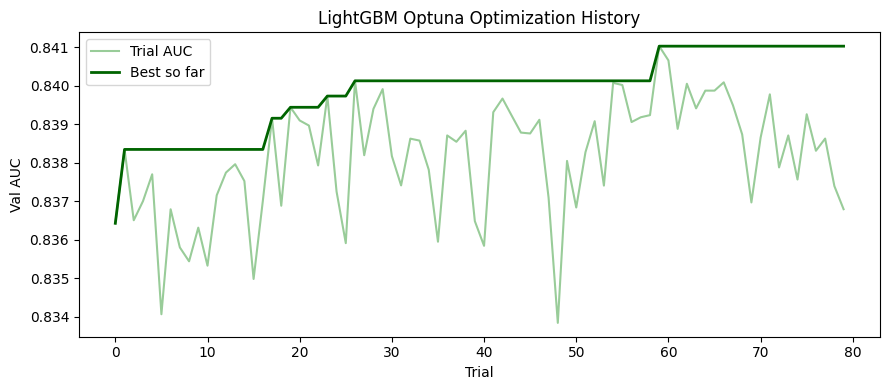

In [32]:
# Phase 1 best params for reference
lgbm_phase1_params = {
    'subsample': 1.0,
    'reg_lambda': 1.0,
    'reg_alpha': 0,
    'num_leaves': 20,
    'n_estimators': 300,
    'min_child_samples': 20,
    'max_depth': 10,
    'learning_rate': 0.01,
    'colsample_bytree': 0.7,
    'scale_pos_weight': 2.7
}

# ─────────────────────────────────────────
# Callback for early stopping in LGBM
# ─────────────────────────────────────────
from lightgbm import early_stopping, log_evaluation
import matplotlib.pyplot as plt


def lgbm_objective(trial):

    params = {
        # Phase 1 found 300; explore wider since lr is still low
        'n_estimators': trial.suggest_int('n_estimators', 200, 700, step=50),

        # Phase 1 found depth=10; explore 7-13
        'max_depth': trial.suggest_int('max_depth', 7, 13),

        # Phase 1 found lr=0.01; tight window around it
        'learning_rate': trial.suggest_float('learning_rate', 0.003, 0.05, log=True),

        # Phase 1 found num_leaves=20; explore 12-40
        'num_leaves': trial.suggest_int('num_leaves', 12, 40),

        # Phase 1 found min_child_samples=20; explore 10-40
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 40),

        # Phase 1 found subsample=1.0; shifted window down slightly
        'subsample': trial.suggest_float('subsample', 0.75, 1.0),

        # Phase 1 found colsample=0.7; tight range around it
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.55, 0.85),

        # Phase 1 found reg_alpha=0; explore 0-0.5
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 0.5),

        # Phase 1 found reg_lambda=1.0; explore 0.5-3
        'reg_lambda': trial.suggest_float('reg_lambda', 0.5, 3.0),

        # Phase 1 found scale_pos_weight=2.7; explore 1.5-4.5
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1.5, 4.5),

        # Extra LGBM-specific params worth exploring
        'min_split_gain': trial.suggest_float('min_split_gain', 0.0, 0.5),
        'subsample_freq': trial.suggest_int('subsample_freq', 1, 5),
    }

    model = LGBMClassifier(
        **params,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )

    model.fit(
        X_train_enc, y_train,
        eval_set=[(X_val_enc, y_val)],
        callbacks=[
            early_stopping(stopping_rounds=40, verbose=False),
            log_evaluation(period=-1)
        ]
    )

    preds = model.predict_proba(X_val_enc)[:, 1]
    return roc_auc_score(y_val, preds)


# ─────────────────────────────────────────
# Run Optuna
# ─────────────────────────────────────────
study_lgbm = optuna.create_study(
    direction='maximize',
    sampler=TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=15)
)

study_lgbm.optimize(
    lgbm_objective,
    n_trials=80,
    show_progress_bar=True
)

# ─────────────────────────────────────────
# Results
# ─────────────────────────────────────────
lgbm_best_params = study_lgbm.best_params

print(f"\n{'='*45}")
print(f"  [LGBM Phase 2] Best Val AUC : {study_lgbm.best_value:.4f}")
print(f"  [LGBM Phase 2] Improvement  : {study_lgbm.best_value - 0.8504:+.4f} over Phase 1")
print(f"{'='*45}")
print(f"  Best Params:\n{lgbm_best_params}")

# ─────────────────────────────────────────
# Optimization history plot
# ─────────────────────────────────────────
trial_values_lgbm = [t.value for t in study_lgbm.trials if t.value is not None]

plt.figure(figsize=(9, 4))
plt.plot(trial_values_lgbm, alpha=0.4, color='green', label='Trial AUC')
plt.plot(pd.Series(trial_values_lgbm).cummax(), color='darkgreen', linewidth=2, label='Best so far')
plt.xlabel('Trial')
plt.ylabel('Val AUC')
plt.title('LightGBM Optuna Optimization History')
plt.legend()
plt.tight_layout()
plt.show()

Phase 2C — Optuna for Catboost

  0%|          | 0/60 [00:00<?, ?it/s]

Best trial: 48. Best value: 0.843139: 100%|██████████| 60/60 [07:36<00:00,  7.60s/it]



  [CatBoost Phase 2] Best Val AUC : 0.8431
  [CatBoost Phase 2] Improvement  : -0.0091 over Phase 1
  Best Params:
{'iterations': 400, 'depth': 5, 'learning_rate': 0.14343748047344063, 'l2_leaf_reg': 6.719179654273406, 'bagging_temperature': 1.1036568304070327, 'border_count': 64, 'random_strength': 2.6011875463135556, 'scale_pos_weight': 4.276934155166999, 'min_data_in_leaf': 22, 'leaf_estimation_iterations': 2}


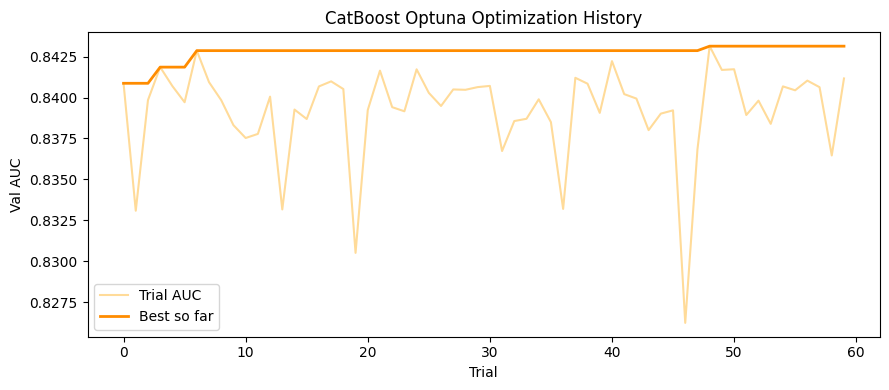


    Model  Phase1_CV_AUC  Phase2_Val_AUC   Delta
 XGBoost         0.8519        0.843590 -0.0083
LightGBM         0.8504        0.841030 -0.0094
CatBoost         0.8522        0.843139 -0.0091


In [33]:
# Phase 1 best params for reference
cb_phase1_params = {
    'iterations': 100,
    'depth': 4,
    'learning_rate': 0.2,
    'l2_leaf_reg': 3.0,
    'bagging_temperature': 1.0,
    'border_count': 32,
    'random_strength': 2.0,
    'scale_pos_weight': 2.5
}

# ─────────────────────────────────────────
# Objective
# ─────────────────────────────────────────
def catboost_objective(trial):

    params = {
        # Phase 1 found 100 with lr=0.2; widen up to explore more trees with lower lr
        'iterations': trial.suggest_int('iterations', 100, 700, step=50),

        # Phase 1 found depth=4; CatBoost optimal range is 4-10; explore 3-8
        'depth': trial.suggest_int('depth', 3, 8),

        # Phase 1 found lr=0.2; explore full practical range
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),

        # Phase 1 found l2=3; explore 1-10
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1.0, 10.0),

        # Phase 1 found bagging_temp=1.0; explore 0-3
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 3.0),

        # Phase 1 found border_count=32; explore more granularity
        'border_count': trial.suggest_categorical('border_count', [32, 64, 128, 254]),

        # Phase 1 found random_strength=2.0; explore 0.5-5
        'random_strength': trial.suggest_float('random_strength', 0.5, 5.0),

        # Phase 1 found scale_pos_weight=2.5; explore 1.0-5.0
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1.0, 5.0),

        # Extra CatBoost-specific params worth exploring
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 1, 30),
        'leaf_estimation_iterations': trial.suggest_int('leaf_estimation_iterations', 1, 10),
    }

    model = CatBoostClassifier(
        **params,
        eval_metric='AUC',
        random_seed=42,
        verbose=0,
        early_stopping_rounds=40
    )

    model.fit(
        train_pool,
        eval_set=val_pool,
        use_best_model=True
    )

    preds = model.predict_proba(val_pool)[:, 1]
    return roc_auc_score(y_val, preds)


# ─────────────────────────────────────────
# Run Optuna
# ─────────────────────────────────────────
study_cb = optuna.create_study(
    direction='maximize',
    sampler=TPESampler(seed=42)
)

study_cb.optimize(
    catboost_objective,
    n_trials=60,          # CatBoost is slower; 60 is enough
    show_progress_bar=True
)

# ─────────────────────────────────────────
# Results
# ─────────────────────────────────────────
cb_best_params = study_cb.best_params

print(f"\n{'='*45}")
print(f"  [CatBoost Phase 2] Best Val AUC : {study_cb.best_value:.4f}")
print(f"  [CatBoost Phase 2] Improvement  : {study_cb.best_value - 0.8522:+.4f} over Phase 1")
print(f"{'='*45}")
print(f"  Best Params:\n{cb_best_params}")

# ─────────────────────────────────────────
# Optimization history plot
# ─────────────────────────────────────────
trial_values_cb = [t.value for t in study_cb.trials if t.value is not None]

plt.figure(figsize=(9, 4))
plt.plot(trial_values_cb, alpha=0.4, color='orange', label='Trial AUC')
plt.plot(pd.Series(trial_values_cb).cummax(), color='darkorange', linewidth=2, label='Best so far')
plt.xlabel('Trial')
plt.ylabel('Val AUC')
plt.title('CatBoost Optuna Optimization History')
plt.legend()
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────
# All 3 Phase 2 results side by side
# ─────────────────────────────────────────
summary_phase2 = pd.DataFrame({
    'Model':         ['XGBoost',  'LightGBM', 'CatBoost'],
    'Phase1_CV_AUC': [0.8519,     0.8504,     0.8522],
    'Phase2_Val_AUC': [study_xgb.best_value, study_lgbm.best_value, study_cb.best_value]
})
summary_phase2['Delta'] = (summary_phase2['Phase2_Val_AUC'] - summary_phase2['Phase1_CV_AUC']).round(4)
print("\n", summary_phase2.to_string(index=False))

## Phase 3 — Final Retrain + Test Set Evaluation

In [34]:
from sklearn.metrics import (
    roc_auc_score, classification_report,
    confusion_matrix, RocCurveDisplay, roc_curve
)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ─────────────────────────────────────────
# Hardcode Phase 2 best params
# ─────────────────────────────────────────
xgb_best_params = {
    'n_estimators'    : 450,
    'max_depth'       : 6,
    'learning_rate'   : 0.028663043261491074,
    'subsample'       : 0.761882304532426,
    'colsample_bytree': 0.46167192866736795,
    'min_child_weight': 9,
    'reg_alpha'       : 0.8321247723666994,
    'reg_lambda'      : 2.0787301751248393,
    'gamma'           : 0.5226874720088373,
    'scale_pos_weight': 2.1500186861909545
}

lgbm_best_params = {
    'n_estimators'    : 650,
    'max_depth'       : 13,
    'learning_rate'   : 0.008535633844517027,
    'num_leaves'      : 13,
    'min_child_samples': 21,
    'subsample'       : 0.7580026562631494,
    'colsample_bytree': 0.6066081804708111,
    'reg_alpha'       : 0.15703551247124883,
    'reg_lambda'      : 2.884795719882881,
    'scale_pos_weight': 1.710339753731322,
    'min_split_gain'  : 0.43601254903789377,
    'subsample_freq'  : 4
}

cb_best_params = {
    'iterations'              : 400,
    'depth'                   : 5,
    'learning_rate'           : 0.14343748047344063,
    'l2_leaf_reg'             : 6.719179654273406,
    'bagging_temperature'     : 1.1036568304070327,
    'border_count'            : 64,
    'random_strength'         : 2.6011875463135556,
    'scale_pos_weight'        : 4.276934155166999,
    'min_data_in_leaf'        : 22,
    'leaf_estimation_iterations': 2
}

# ─────────────────────────────────────────
# Combine train + val for final training
# ─────────────────────────────────────────
X_trainval_enc = np.vstack([X_train_enc, X_val_enc])
y_trainval     = pd.concat([y_train, y_val]).reset_index(drop=True)

# CatBoost combined pool
X_trainval_cb = pd.concat([X_train_cb, X_val_cb]).reset_index(drop=True)
trainval_pool  = Pool(X_trainval_cb, y_trainval, cat_features=cat_feature_indices)

# ─────────────────────────────────────────
# Retrain XGBoost
# ─────────────────────────────────────────
final_xgb = XGBClassifier(
    **xgb_best_params,
    eval_metric='auc',
    use_label_encoder=False,
    random_state=42,
    n_jobs=-1
)
final_xgb.fit(X_trainval_enc, y_trainval)
print("XGBoost retrained ✅")

# ─────────────────────────────────────────
# Retrain LightGBM
# ─────────────────────────────────────────
final_lgbm = LGBMClassifier(
    **lgbm_best_params,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
final_lgbm.fit(X_trainval_enc, y_trainval)
print("LightGBM retrained ✅")

# ─────────────────────────────────────────
# Retrain CatBoost
# ─────────────────────────────────────────
final_cb = CatBoostClassifier(
    **cb_best_params,
    eval_metric='AUC',
    random_seed=42,
    verbose=0
)
final_cb.fit(trainval_pool)
print("CatBoost retrained ✅")

XGBoost retrained ✅
LightGBM retrained ✅
CatBoost retrained ✅



 Final Test Set Comparison:
   Model  Test_AUC  Precision  Recall     F1
LightGBM    0.8406     0.5600  0.7000 0.6222
CatBoost    0.8367     0.4601  0.8643 0.6005
 XGBoost    0.8287     0.5282  0.7036 0.6034

 Classification Report — LightGBM:
              precision    recall  f1-score   support

    No Churn       0.88      0.80      0.84       775
       Churn       0.56      0.70      0.62       280

    accuracy                           0.77      1055
   macro avg       0.72      0.75      0.73      1055
weighted avg       0.80      0.77      0.78      1055



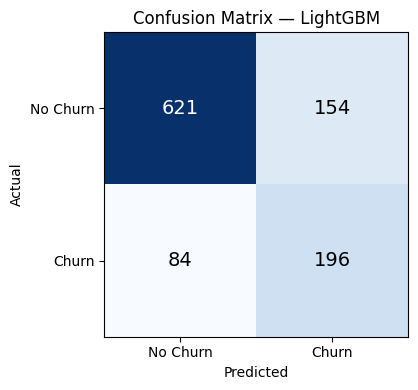

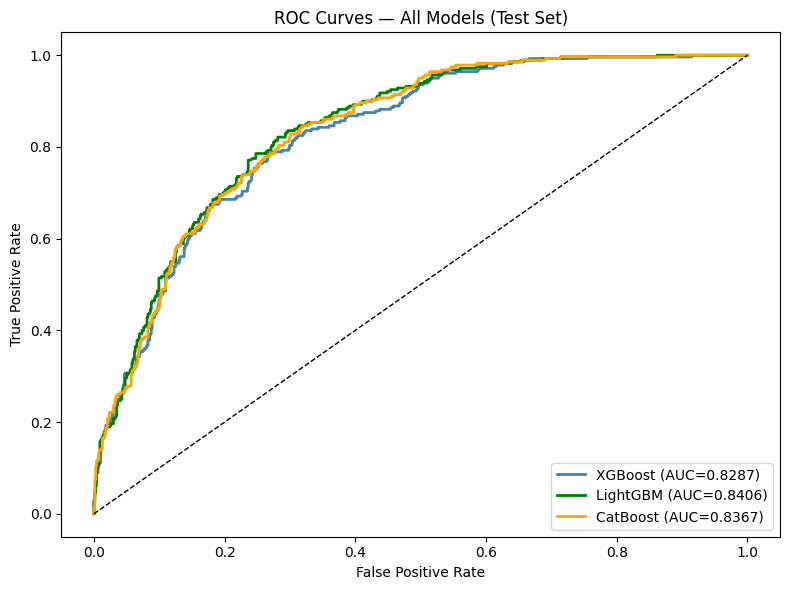

In [35]:
# ─────────────────────────────────────────
# Predict on test set
# ─────────────────────────────────────────
xgb_proba  = final_xgb.predict_proba(X_test_enc)[:, 1]
lgbm_proba = final_lgbm.predict_proba(X_test_enc)[:, 1]
cb_proba   = final_cb.predict_proba(test_pool)[:, 1]

xgb_pred   = final_xgb.predict(X_test_enc)
lgbm_pred  = final_lgbm.predict(X_test_enc)
cb_pred    = final_cb.predict(test_pool)

# ─────────────────────────────────────────
# Metrics per model
# ─────────────────────────────────────────
models_eval = {
    'XGBoost':  (xgb_proba,  xgb_pred),
    'LightGBM': (lgbm_proba, lgbm_pred),
    'CatBoost': (cb_proba,   cb_pred)
}

from sklearn.metrics import precision_score, recall_score, f1_score

rows = []
for name, (proba, pred) in models_eval.items():
    auc  = roc_auc_score(y_test, proba)
    prec = precision_score(y_test, pred)
    rec  = recall_score(y_test, pred)
    f1   = f1_score(y_test, pred)
    rows.append({'Model': name, 'Test_AUC': round(auc,4),
                 'Precision': round(prec,4), 'Recall': round(rec,4), 'F1': round(f1,4)})

results_df = pd.DataFrame(rows).sort_values('Test_AUC', ascending=False)
print("\n Final Test Set Comparison:")
print(results_df.to_string(index=False))

# ─────────────────────────────────────────
# Detailed report for best model
# ─────────────────────────────────────────
best_model_name = results_df.iloc[0]['Model']
best_proba, best_pred = models_eval[best_model_name]

print(f"\n Classification Report — {best_model_name}:")
print(classification_report(y_test, best_pred, target_names=['No Churn', 'Churn']))

# ─────────────────────────────────────────
# Confusion matrix for best model
# ─────────────────────────────────────────
cm = confusion_matrix(y_test, best_pred)
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(['No Churn', 'Churn'])
ax.set_yticklabels(['No Churn', 'Churn'])
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha='center', va='center', fontsize=14,
                color='white' if cm[i, j] > cm.max()/2 else 'black')
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix — {best_model_name}')
plt.tight_layout(); plt.show()

# ─────────────────────────────────────────
# ROC curves — all 3 models overlaid
# ─────────────────────────────────────────
colors = {'XGBoost': 'steelblue', 'LightGBM': 'green', 'CatBoost': 'orange'}

plt.figure(figsize=(8, 6))
for name, (proba, _) in models_eval.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.4f})", color=colors[name], linewidth=2)

plt.plot([0,1], [0,1], 'k--', linewidth=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Models (Test Set)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

Step 1 — Threshold Tuning (most impactful, do this first)

Default threshold (0.5) → Precision: 0.50 | Recall: 0.82 | F1: 0.62
Optimal threshold (0.447) → Precision: 0.54 | Recall: 0.77 | F1: 0.64


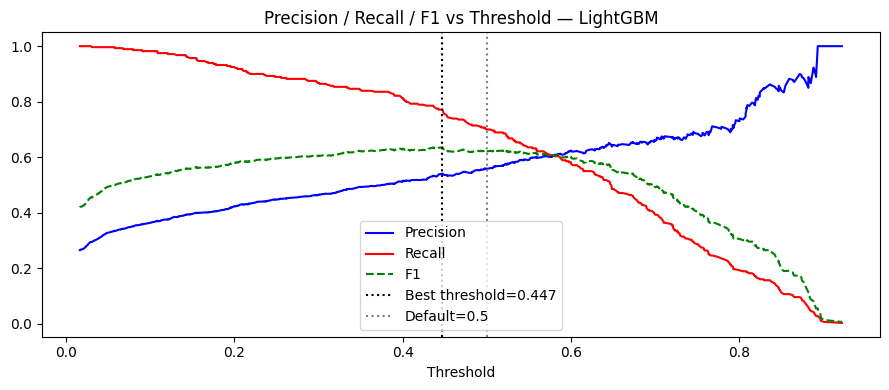


Classification Report after threshold tuning:
              precision    recall  f1-score   support

    No Churn       0.90      0.76      0.83       775
       Churn       0.54      0.77      0.64       280

    accuracy                           0.77      1055
   macro avg       0.72      0.77      0.73      1055
weighted avg       0.81      0.77      0.78      1055



In [36]:
from sklearn.metrics import precision_recall_curve, f1_score
import numpy as np
import matplotlib.pyplot as plt

lgbm_proba = final_lgbm.predict_proba(X_test_enc)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_test, lgbm_proba)

f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
best_thresh_idx = np.argmax(f1_scores)
best_threshold  = thresholds[best_thresh_idx]

print(f"Default threshold (0.5) → Precision: 0.50 | Recall: 0.82 | F1: 0.62")
print(f"Optimal threshold ({best_threshold:.3f}) → "
      f"Precision: {precisions[best_thresh_idx]:.2f} | "
      f"Recall: {recalls[best_thresh_idx]:.2f} | "
      f"F1: {f1_scores[best_thresh_idx]:.2f}")

# Plot Precision-Recall tradeoff
plt.figure(figsize=(9, 4))
plt.plot(thresholds, precisions[:-1], label='Precision', color='blue')
plt.plot(thresholds, recalls[:-1],    label='Recall',    color='red')
plt.plot(thresholds, f1_scores[:-1],  label='F1',        color='green', linestyle='--')
plt.axvline(best_threshold, color='black', linestyle=':', label=f'Best threshold={best_threshold:.3f}')
plt.axvline(0.5, color='gray', linestyle=':', label='Default=0.5')
plt.xlabel('Threshold')
plt.title('Precision / Recall / F1 vs Threshold — LightGBM')
plt.legend()
plt.tight_layout()
plt.show()

# Apply best threshold
y_pred_tuned = (lgbm_proba >= best_threshold).astype(int)
print("\nClassification Report after threshold tuning:")
print(classification_report(y_test, y_pred_tuned, target_names=['No Churn', 'Churn']))

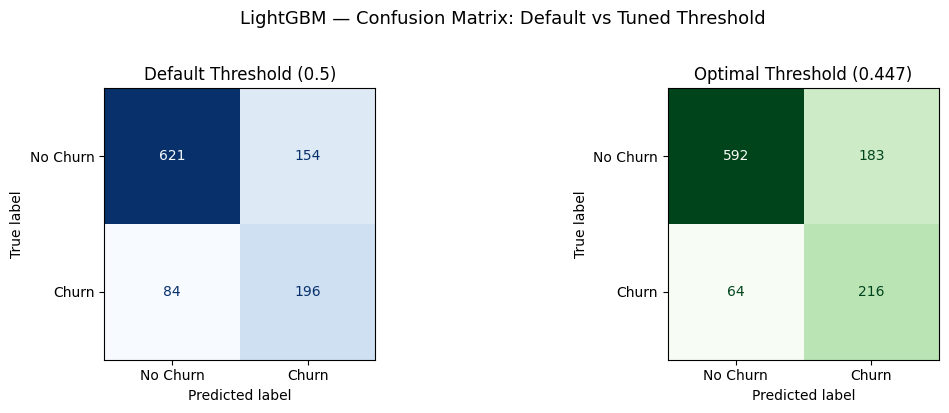


Metric                     Default (0.5)  Tuned (0.447)      Delta
─────────────────────────────────────────────────────────────────
True Positives (TP)                  196            216        +20
False Negatives (FN)                  84             64        -20
False Positives (FP)                 154            183        +29
True Negatives (TN)                  621            592        -29


In [37]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Compute confusion matrix using the tuned threshold predictions
cm = confusion_matrix(y_test, y_pred_tuned)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ─────────────────────────────────────────
# Left: Default threshold (0.5)
# ─────────────────────────────────────────
y_pred_default = (lgbm_proba >= 0.5).astype(int)
cm_default = confusion_matrix(y_test, y_pred_default)

disp_default = ConfusionMatrixDisplay(
    confusion_matrix=cm_default,
    display_labels=['No Churn', 'Churn']
)
disp_default.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Default Threshold (0.5)', fontsize=12)

# ─────────────────────────────────────────
# Right: Optimal threshold
# ─────────────────────────────────────────
disp_tuned = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['No Churn', 'Churn']
)
disp_tuned.plot(ax=axes[1], colorbar=False, cmap='Greens')
axes[1].set_title(f'Optimal Threshold ({best_threshold:.3f})', fontsize=12)

plt.suptitle('LightGBM — Confusion Matrix: Default vs Tuned Threshold', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────
# Print delta summary
# ─────────────────────────────────────────
tn_d, fp_d, fn_d, tp_d = cm_default.ravel()
tn_t, fp_t, fn_t, tp_t = cm.ravel()

print(f"\n{'Metric':<25} {'Default (0.5)':>14} {'Tuned ({:.3f})'.format(best_threshold):>14} {'Delta':>10}")
print("─" * 65)
print(f"{'True Positives (TP)':<25} {tp_d:>14} {tp_t:>14} {tp_t - tp_d:>+10}")
print(f"{'False Negatives (FN)':<25} {fn_d:>14} {fn_t:>14} {fn_t - fn_d:>+10}")
print(f"{'False Positives (FP)':<25} {fp_d:>14} {fp_t:>14} {fp_t - fp_d:>+10}")
print(f"{'True Negatives (TN)':<25} {tn_d:>14} {tn_t:>14} {tn_t - tn_d:>+10}")